# Zadanie regresji dla zbioru
Ze względu na trudny charakter zbioru dla zadania klasyfikacji
- dużego overlapu klas,
- niewielkiej liczby próbek klas skrajnych.

postanowiliśmy przeprowadzić eksperyment dla zadania regresji z wykorzystaniem metryk MAE, RESM i R2.

### Klasyfikacja  - przypisywanie wina do konkretnej klasy

### Regresja  - przewidywanie liczbowej jakości wina

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

from src.data_loader import load_data
from src.regression import evaluate_regression
from src.preprocessing import prepare_data

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")
plt.style.use('default')  # reset stylu
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

In [2]:
# LOAD
df = load_data("../Dataset/WineQT.csv")

# Mod "basic" dla wszystkich 6 klas
mode = "basic"

# preprocess
X, y = prepare_data(df, mode = mode)

# CV
cv = KFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

Rozkład klas (po połączeniu klas):
quality
5    483
6    462
7    143
4     33
8     16
3      6
Name: count, dtype: int64


In [3]:
models = {
    "LinearRegression": LinearRegression(),
    "DecisionTreeRegressor": DecisionTreeRegressor(random_state=42),
    "HistGradientBoostingRegressor": HistGradientBoostingRegressor(random_state=42),
    "RandomForestRegressor": RandomForestRegressor(random_state=42)
}

In [4]:
# EXPERIMENTS

results = []

for name, model in models.items():

    print(f"\n===== {name} =====")

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    scores = evaluate_regression(
        pipe,
        X,
        y,
        cv
    )

    print(scores)

    results.append({
        "model": name,
        **scores
    })


===== LinearRegression =====
{'MAE': '0.501 (0.028)', 'RMSE': '0.645 (0.044)', 'R2': '0.354 (0.033)'}

===== DecisionTreeRegressor =====
{'MAE': '0.493 (0.069)', 'RMSE': '0.813 (0.090)', 'R2': '-0.032 (0.162)'}

===== HistGradientBoostingRegressor =====
{'MAE': '0.446 (0.023)', 'RMSE': '0.612 (0.041)', 'R2': '0.416 (0.048)'}

===== RandomForestRegressor =====
{'MAE': '0.433 (0.027)', 'RMSE': '0.588 (0.053)', 'R2': '0.463 (0.047)'}


In [5]:
results_df = pd.DataFrame(results)

print("\n===== FINAL RESULTS =====")
print(results_df)
results_df.to_csv("../charts/regression_results.csv")


===== FINAL RESULTS =====
                           model            MAE           RMSE              R2
0               LinearRegression  0.501 (0.028)  0.645 (0.044)   0.354 (0.033)
1          DecisionTreeRegressor  0.493 (0.069)  0.813 (0.090)  -0.032 (0.162)
2  HistGradientBoostingRegressor  0.446 (0.023)  0.612 (0.041)   0.416 (0.048)
3          RandomForestRegressor  0.433 (0.027)  0.588 (0.053)   0.463 (0.047)


## Najlepiej działały modele ensemble

Najwyższe wyniki osiągnęły:

- RandomForestRegressor,
- HistGradientBoostingRegressor.

Pokazuje to, że:

- zależności w danych są nieliniowe,
- pojedyncze modele liniowe lub pojedyncze drzewa są niewystarczające.

0.3244682462331229


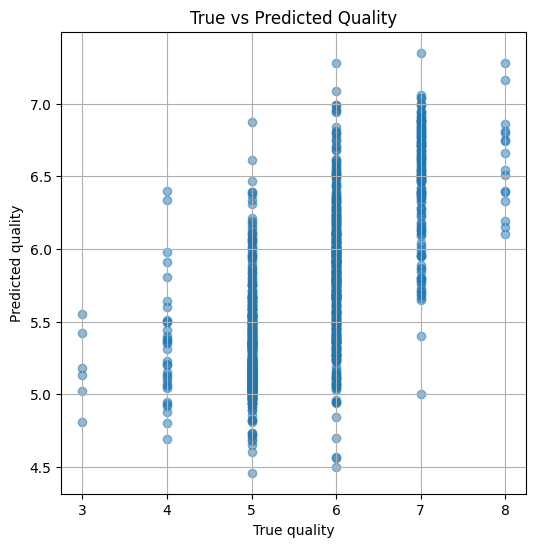

In [6]:
y_pred = cross_val_predict(
    pipe,
    X,
    y,
    cv=cv
)
from sklearn.metrics import f1_score
y_pred_reg = np.round(y_pred)
print(f1_score(y, y_pred_reg, average="macro"))

plt.figure(figsize=(6,6))

plt.scatter(y, y_pred, alpha=0.5)

plt.xlabel("True quality")
plt.ylabel("Predicted quality")

plt.title("True vs Predicted Quality")

plt.grid(True)
plt.savefig("../charts/regression_truequality.png")
plt.show()

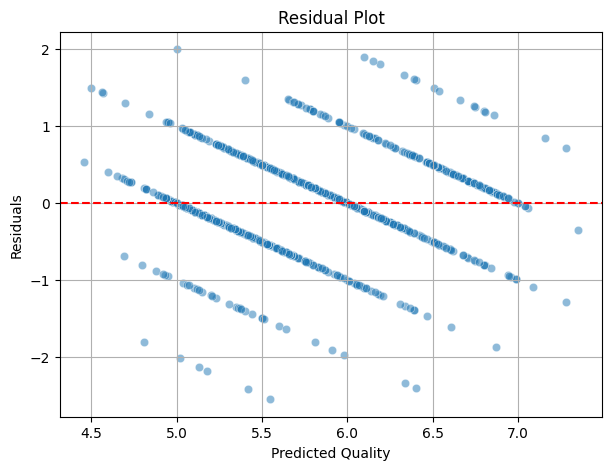

In [7]:
residuals = y - y_pred

plt.figure(figsize=(7,5))

sns.scatterplot(
    x=y_pred,
    y=residuals,
    alpha=0.5
)

plt.axhline(0, linestyle="--", color="red")

plt.xlabel("Predicted Quality")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.grid(True)
plt.savefig("../charts/regression_residuals.png")
plt.show()

## Interpretacja wykresu True vs Predicted

Model poprawnie uchwycił ogólną zależność między cechami chemicznymi a jakością wina. Wraz ze wzrostem rzeczywistej jakości rosły również przewidywania modelu. Jednocześnie widoczne było zjawisko „ściągania do średniej”, gdzie wartości skrajne były przewidywane mniej dokładnie.

## Interpretacja residual plot

Residual plot nie wykazał silnych systematycznych wzorców błędów. Residuale były względnie symetryczne względem zera, co sugeruje brak dużego biasu modelu. Widoczne ukośne pasy wynikają z dyskretnego charakteru zmiennej quality oraz ciągłych predykcji modelu regresyjnego.

Impact of Features on Wine Quality for Linear Regression

                 Feature    Factor
10               alcohol  0.303037
1       volatile acidity -0.202735
9              sulphates  0.149068
6   total sulfur dioxide -0.091256
4              chlorides -0.080705
8                     pH -0.063923
0          fixed acidity  0.040133
7                density -0.033576
2            citric acid -0.025924
5    free sulfur dioxide  0.024277
3         residual sugar  0.018313


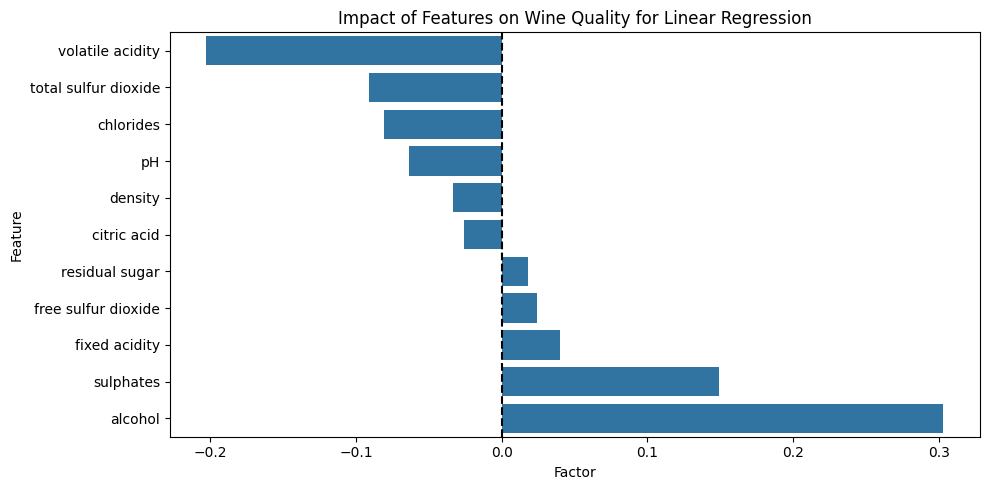



Analiza underfitting i overfitting dla modeli:


[LinearRegression]
R2:   Train = 0.375 | CV Test = 0.354
MAE:  Train = 0.494 | CV Test = 0.501
RMSE: Train = 0.637 | CV Test = 0.645

[DecisionTreeRegressor]
R2:   Train = 1.000 | CV Test = -0.032
MAE:  Train = -0.000 | CV Test = 0.493
RMSE: Train = -0.000 | CV Test = 0.813

[HistGradientBoostingRegressor]
R2:   Train = 0.934 | CV Test = 0.416
MAE:  Train = 0.151 | CV Test = 0.446
RMSE: Train = 0.207 | CV Test = 0.612

[RandomForestRegressor]
R2:   Train = 0.924 | CV Test = 0.463
MAE:  Train = 0.160 | CV Test = 0.433
RMSE: Train = 0.222 | CV Test = 0.588


In [8]:
print("Impact of Features on Wine Quality for Linear Regression\n")
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])
pipe.fit(X, y)

coefficients = pipe.named_steps["model"].coef_
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Factor': coefficients,
    'Absolute Value Factor': np.abs(coefficients)
}).sort_values(by='Absolute Value Factor', ascending=False)

print(feature_importance[['Feature', 'Factor']])

plt.figure(figsize=(10, 5))
sns.barplot(x='Factor', y='Feature', data=feature_importance.sort_values(by='Factor'))
plt.title("Impact of Features on Wine Quality for Linear Regression")
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.savefig("../charts/linear_regression_feature_importance.png")
plt.show()


print("\n\nAnaliza underfitting i overfitting dla modeli:\n")

scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2"
}

for name, model in models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    cv_results = cross_validate(pipe, X, y, cv=cv, scoring=scoring, return_train_score=True)

    print(f"\n[{name}]")
    print(f"R2:   Train = {cv_results['train_r2'].mean():.3f} | CV Test = {cv_results['test_r2'].mean():.3f}")
    print(f"MAE:  Train = {-cv_results['train_mae'].mean():.3f} | CV Test = {-cv_results['test_mae'].mean():.3f}")
    print(f"RMSE: Train = {-cv_results['train_rmse'].mean():.3f} | CV Test = {-cv_results['test_rmse'].mean():.3f}")


### Ważność poszczególnych cech w Regresji Liniowej

Najważniejszymi pozytywnymi czynnikami determinującym wysoką jakość wina są cechy:
- alcohol o współczynniku $+0.303$
- sulphates o współczynnik $+0.149$

Najważniejszymi negatywnymi czynnikami determinującym wysoką jakość wina są cechy:
- volatile acidity o współczynniku $-0.203$
- total sulfur dioxide o współczynniku $-0.091$
- chlorides o współczynniku $-0.081$

Pozostałe cechy (np. residual sugar czy free sulfur dioxide) mają minimalny wpływ na wynik tego modelu.


### Analiza underfittingu i overfittingu
Porównując dopasowanie modeli na zbiorze treningowym oraz testowym (pochodzącym z walidacji krzyżowej), można zaobserwować trzy różne zachowania algorytmów:

- **LinearRegression**: Model wykazuje underfitting. Wyniki dla zbioru treningowego oraz testowego są bardzo zbliżone. Oznacza to, że model stabilnie generalizuje wiedzę, ale jego struktura jest zbyt prosta – nie jest w stanie wyłapać nieliniowych zależności chemicznych decydujących o smaku i jakości wina
- **DecisionTreeRegressor**: Model wykazuje wysoki overfitting. Na zbiorze treningowym osiąga idealny wynik $R^2 = 1.000$, co oznacza, że "zapamiętało" każdą próbkę z treningu. Jednak na zbiorze testowym model sobie nie radzi, osiągając ujemny wynik $R^2 = -0.032$
- **HistGradientBoostingRegressor** i **RandomForestRegressor**: Modele te stanowią najlepszy kompromis. W przypadku `HistGradientBoostingRegressor` widzimy wysokie dopasowanie do danych treningowych ($R^2 = 0.934$) oraz wyraźny spadek na zbiorze testowym ($R^2 = 0.416$). Choć występuje tu zauważalny overfitting (różnica $0.518$), to modele te wciąż osiągają najwyższą zdolność predykcyjną na nieznanych danych spośród reszty testowanych algorytmów


## Odpowiedzi na pytania z laboratorium

### 1. Czy accuracy wystarcza do oceny tego modelu?
Nie, nie wystarcza. Nasz zbiór danych (WineQT) charakteryzuje się bardzo silnym niezbalansowaniem klas. Wina o jakości "5" i "6" stanowią przytłaczającą większość (945 z 1143 próbek), w trakcie, kiedy win o skrajnej jakości (3 oraz 8) jest łącznie 22. W takim przypadku klasyfikator, który przypisywałby każdemu winu klasę "5", uzyskałby relatywnie wysokie accuracy, całkowicie ignorując pozostałe klasy.

### 2. W jakiej sytuacji ROC AUC byłby ważniejszy niż accuracy?
Metryka ROC AUC byłaby ważniejsza niż accuracy w przypadku pracowania z niezbalansowanymi klasami, ponieważ ROC AUC ocenia zdolność modelu do odróżniania klasy pozytywnej od negatywnej niezależnie od ich proporcji w zbiorze danych.

### 3. Jak interpretować znak i wartość współczynników w regresji logistycznej?

- Znak dodatni współczynnika oznacza, że wraz ze wzrostem danej cechy rośnie prawdopodobieństwo przypisania próbki do klasy pozytywnej. Znak ujemny, natomiast oznacza, że wzrost cechy zmniejsza to prawdopodobieństwo.
- Wartość współczynnika określa siłę tego wpływu. Otrzymany wynik mówi nam, ile razy wzrosną lub spadną szanse na klasę pozytywną przy zmianie wartości cechy o jednostkę.
